In [529]:
"""
Makes a catalogue of morphological data for my galaxies. Creates fits data file Galaxy_morphology.
"""

from astropy.io import fits
from astropy.table import Table
from astropy.table import vstack
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import os
import corner
#import asdf
from tqdm import tqdm
#from photutils.aperture import EllipticalAperture
from astropy.table import Table, vstack, join

CSV_DIR = "/nvme/scratch/work/alberttg/Summer_project/csv_tables"

SERSIC_RESULTS_DIR = "/nvme/scratch/work/alberttg/Summer_project/Data_products/Pysersic_results_0p96as"

with fits.open("/nvme/scratch/work/alberttg/Summer_project/Ha_and_NII_broad_line_data.fits") as hdul:
        data = hdul[1].data
TABLE = Table(data)


GALAXY_ID = np.asarray(TABLE["SURVEY_ID"], dtype=int)      # object ID, used for labeling/output files
SERSIC_FILTERS = ["F444W","F356W","F277W"]                    # filter name, used for labeling/output files
SURVEY = np.asarray(TABLE["SURVEY"], dtype=str)
REDSHIFT = np.asarray(TABLE["REDSHIFT"], dtype=float)

PIXEL_SIZE = 0.03 #as

COSMO = FlatLambdaCDM(H0=70, Om0=0.3)



In [530]:
from astropy.visualization import ImageNormalize, AsinhStretch, PercentileInterval

def plot_science_model_residual(
    science,
    model,
    residual=None,
    percentile=99.5,
    cmap="gray",
    residual_cmap="RdBu_r",
    figsize=(12, 4),
):
    """
    Plot science image, best-fit model, and residual side-by-side.
    I only needed this because the double sersic run didn't save any images.

    Parameters
    ----------
    science : 2D ndarray
        Science image.
    model : 2D ndarray
        Best-fit model image.
    residual : 2D ndarray, optional
        Residual image. If None, computed as science - model.
    percentile : float
        Percentile used for image normalization.
    cmap : str
        Colormap for science/model.
    residual_cmap : str
        Colormap for residual.
    figsize : tuple
        Figure size.
    """

    if residual is None:
        residual = science - model

    # Shared normalization for science/model
    interval = PercentileInterval(percentile)
    vmin, vmax = interval.get_limits(
        np.concatenate([science.ravel(), model.ravel()])
    )

    norm = ImageNormalize(
        vmin=vmin,
        vmax=vmax,
        stretch=AsinhStretch(),
    )

    # Symmetric residual scaling
    rlim = np.nanpercentile(np.abs(residual), percentile)

    fig, axes = plt.subplots(
        1, 3,
        figsize=figsize,
        constrained_layout=True,
    )

    images = [
        (science, "Science", cmap, norm),
        (model, "Best Model", cmap, norm),
        (
            residual,
            "Residual",
            residual_cmap,
            dict(vmin=-rlim, vmax=rlim),
        ),
    ]

    for ax, (img, title, cmap_i, norm_i) in zip(axes, images):

        if isinstance(norm_i, dict):
            im = ax.imshow(
                img,
                origin="lower",
                cmap=cmap_i,
                **norm_i,
            )
        else:
            im = ax.imshow(
                img,
                origin="lower",
                cmap=cmap_i,
                norm=norm_i,
            )

        ax.set_title(title, fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])

        plt.colorbar(
            im,
            ax=ax,
            fraction=0.046,
            pad=0.04,
        )

    return fig, axes

In [531]:
def read_summary_table(path, parameter):
    """
    Extracts the mean and sd values for a given parameter from the sersic summary tables.
    """
    csv_table = pd.read_csv(path, index_col=0)
    
    row = csv_table.loc[parameter]
    return row["mean"], row["sd"]

In [532]:
def double_sersic_data(galaxy_id, filt, asdf_path, output_dir):
    """
    The double sersic fit run didn't save the data/model/residual fits file or any images. Don't need this anymore.
    """

    os.makedirs(output_dir, exist_ok=True)
    tag = f"{galaxy_id}_{filt}"

    with asdf.open(asdf_path) as af:
        model = np.asarray(af.tree['best_model'])
        image = np.asarray(af.tree["input_data"]['image'])
        mask = np.asarray(af.tree["input_data"]['mask'])
        rms = np.asarray(af.tree["input_data"]['rms'])

        fits_path = os.path.join(output_dir, f"{tag}_data_model_residual.fits")

        residual = image - model

        hdul = fits.HDUList([
            fits.PrimaryHDU(),                              # Empty primary HDU
            fits.ImageHDU(image, name="SCIENCE_IMAGE"),         # Extension 1
            fits.ImageHDU(model, name="MODEL"),             # Extension 2
            fits.ImageHDU(residual, name="RESIDUAL"),       # Extension 3
            fits.ImageHDU(mask.astype("uint8"), name="MASK"),  # Extension 4
            fits.ImageHDU(rms, name="RMS"),                 # Extension 5
        ])
        # Fits path
        hdul.writeto(fits_path, overwrite=True)
        hdul.close()
        print(f"[{tag}] Saved FITS residual file to {fits_path}")

        # residual figure
        fig_resid, _ = plot_science_model_residual(image, model, residual)
        fig_resid.suptitle(f"{galaxy_id} - {filt}: data / model / residual")
        resid_path = os.path.join(output_dir, f"{tag}_data_model_residual.png")
        fig_resid.savefig(resid_path, dpi=150, bbox_inches="tight")
        print(f"[{tag}] Saved data/model/residual plot to {resid_path}")
        plt.close(fig_resid)

        # Corner plot
        posterior = af.tree["posterior"]

        labels = list(posterior.keys())

        samples = np.column_stack([
            np.asarray(posterior[p]).reshape(-1)
            for p in labels
        ])

        fig_corner = corner.corner(
            samples,
            labels=labels,
            show_titles=True,
            title_fmt=".3f",
        )

        fig_corner.suptitle(f"{galaxy_id} - {filt}: posterior corner plot")
        corner_path = os.path.join(output_dir, f"{tag}_corner.png")
        fig_corner.savefig(corner_path, dpi=150, bbox_inches="tight")
        plt.close(fig_corner)


In [533]:
def read_residual_fits_table(path):
    """
    Opens data_model_residual fits files and returns data for sersic model and residual.
    """
    with fits.open(path) as hdul:
        sci_im = hdul[1].data
        sersic_model = hdul[2].data
        residual = hdul[3].data
        mask = hdul[4].data
        mask = mask.astype(bool)
        rms = hdul[5].data

    return sci_im, sersic_model, residual, mask, rms

In [534]:
def calculate_RFF(sci_im, sersic_model, rms, mask, flux_auto, flux_radius, x0, y0):
    """
    Formula for RFF from EPOCHS XI eq 4.

    Parameters
    ----------
    sci_im : array
        science image
    sersic_model : array
        Sersic model data
    mask : array
        mask map
    rms : array
        map of background noise
    flux_auto : float
        Flux of galaxy measured through SExtractor
    flux_radius : float
        Half-light radius measurement measured with SExtractor
    x0 : float
        x pixel position of galaxy centre as fit by Pysersic
    y0 : float
        y pixel position of galaxy centre as fit by Pysersic
    """

    y, x = np.indices(sci_im.shape)

    r = np.sqrt((x - x0)**2 + (y - y0)**2)
    # Uses x0 and y0 from model

    rff_region = r <= 2 * flux_radius
    # Defines what region is the galaxy and therefore where RFF can be meaningfully calculated
    # print(np.where(rff_region==True))
    # Remove contaminating sources
    good_pixels = rff_region & (~mask) & np.isfinite(rms) & (rms != 0)
    
    # Number of pixels in aperture (RFF is calculated within twice flux_radius)
    N_pixels = np.nansum(good_pixels)

    background_values = sci_im[~mask.astype(bool)]
    depth_1sig = 1.4826 * np.nanmedian(np.abs(background_values - np.nanmedian(background_values)))

    residuals = sci_im[good_pixels] - sersic_model[good_pixels]

    rff = ( np.nansum(np.abs(residuals)) - 0.8 * depth_1sig * N_pixels)  / flux_auto
    # Must restrict the residual map to the region where RFF is defined (twice flux_radius)

    return rff

In [535]:
def reduced_chi_squared(image, model, rms, mask, n_params):
    """
    Calulcates reduced chi squared between model and science image.
    n_params is 7: amplitude, sersic_rhalf, sersic_n, sersic_xc, sersic_yc, sersic_ellip, sersic_theta.
    """

    valid = (~mask) & np.isfinite(rms) & (rms != 0)

    chi2 = np.sum(((image[valid] - model[valid]) / rms[valid])**2)

    dof = np.sum(valid) - n_params

    return chi2 / dof

In [536]:
def _calc_RFF(sci_im, model, residuals, mask, a_image_as, b_image_as, theta_image):
        """
        NOT USED!!
        Calculates the Residual Flux Fraction (RFF) for a given galaxy.

        Parameters
        ----------
        model : array
            Sersic model data
        residuals : array
            Residuals bewteen science image and model
        mask : array of bool
            Mask map
        a_image_as : float
            Semi major axis of elliptical aperture used in image (units of as)
        b_image_as : float
            Semi minor axis of elliptical aperture used in image (units of as)
        theta_image : float
            Angle of orientation of elliptical aperture used in image (degrees?)
        """
        # -> Kron radius too small
        # -> elliptical aperture also too small

        pix_scale = CUTOUT_SIZE / PIXEL_SIZE
        # reconstruct Kron elliptical aperture
        # EllipticalAperture models an elliptical aperture taking 5 parameters: x0, y0, a, b, orientation
        kron_aper = EllipticalAperture(
            (PIXEL_SIZE / 2, PIXEL_SIZE / 2),
            a_image_as / pix_scale,
            b_image_as / pix_scale,
            theta_image,
        )
        residuals = np.abs(residuals) 
        model_kron = kron_aper.do_photometry(model)[0][0]
        residual_kron = kron_aper.do_photometry(residuals)[0][0]

        # Mask all sources except those within Kron aperture
        mask[mask != 0] = 1
        background_values = sci_im[~mask.astype(bool)]
        abs_deviation = np.abs(background_values - np.nanmedian(background_values))
        depth_1sig = 1.4826 * np.nanmedian(abs_deviation)

        rff = (residual_kron - 0.8 * depth_1sig * kron_aper.area) / model_kron
        return rff

In [537]:
def calculate_BIC(sci_im, sersic_model, mask, rms, flux_radius, n_params):
    """
    Calculates BIC, assuming Gaussian pixel uncertainties.
    Adds error floor whereby, the uncertainties (which I think are underestimated)
    are increased by 10% of the science image flux value.
    """
    ny, nx = sci_im.shape
    y0, x0 = ny // 2, nx // 2

    y, x = np.indices(sci_im.shape)

    r = np.sqrt((x - x0)**2 + (y - y0)**2)

    region = r <= 2 * flux_radius
    # Defines what region is the galaxy and therefore where RFF can be meaningfully calculated

    # Remove contaminating sources and ensure that rms is not Nan nor zero
    good_pixels = (region & (~mask) & np.isfinite(rms) & (rms != 0))
    
    # Number of pixels in aperture (RFF is calculated within twice flux_radius)
    N_pixels = np.nansum(good_pixels)

    residuals = sci_im[good_pixels] - sersic_model[good_pixels]

    #Error floor with 10% of obsverved flux value, which is standard in literature (J. Silva)
    err = np.sqrt( rms[good_pixels]**2 + (0.10 * sci_im[good_pixels])**2 ) 
    # TODO: Check that this error floor is appropriate
    
    # log-likelihood for Gaussian pixel uncertainties
    ln_L = -0.5 * np.nansum( residuals**2 / err**2 + np.log(2 * np.pi * err**2) )

    bic = n_params * np.log(N_pixels) - 2 * ln_L

    return bic

In [538]:
def convert_pixel_to_kpc(radius_pix, redshift):
    '''
    Converts r_eff in pixels, which is what pysersic and morphometryka output, into kpc.
    '''
    pixel_scale = 0.03 * u.arcsec

    kpc_per_arcsec = COSMO.kpc_proper_per_arcmin(redshift).to(u.kpc/u.arcsec)

    radius_kpc = radius_pix * pixel_scale * kpc_per_arcsec
    # Return .value so that an Astropy Quantity is not returned instead
    return (radius_kpc).value


In [539]:
def make_single_sersic_table(folder):
    """
    Makes a FITS table of morphological parameters for each galaxy.
    Each galaxy occupies a single row, with separate columns for each filter.
    """

    rows = []

    for i in tqdm(range(len(GALAXY_ID)), total=len(GALAXY_ID)):
        # Start the row with the galaxy information
        row = {
            "SURVEY_ID": GALAXY_ID[i],
            "SURVEY": SURVEY[i],
            "REDSHIFT": REDSHIFT[i],
        }

        # Add morphology measurements for each filter
        for filt in SERSIC_FILTERS:

            summary_path = os.path.join(SERSIC_RESULTS_DIR, f"{folder}/{GALAXY_ID[i]}/{GALAXY_ID[i]}_{filt}_summary.csv")
            summary_path = Path(summary_path)
            
            if summary_path.exists():
                ellip_mean, ellip_sd = read_summary_table(summary_path, "ellip")
                n_mean, n_sd = read_summary_table(summary_path, "n")
                r_eff_mean, r_eff_sd = read_summary_table(summary_path, "r_eff")
                r_eff_mean = convert_pixel_to_kpc(r_eff_mean, REDSHIFT[i])
                r_eff_sd = convert_pixel_to_kpc(r_eff_sd, REDSHIFT[i])
                
                xc, _ = read_summary_table(summary_path, "xc")
                yc, _ = read_summary_table(summary_path, "yc")
            else:
                ellip_mean = ellip_sd = np.nan
                n_mean = n_sd = np.nan
                r_eff_mean = r_eff_sd = np.nan
                xc = np.nan
                yc = np.nan

            row[f"{filt}_ellip_mean"] = ellip_mean
            row[f"{filt}_ellip_sd"] = ellip_sd
            row[f"{filt}_n_mean"] = n_mean
            row[f"{filt}_n_sd"] = n_sd
            row[f"{filt}_r_eff_mean"] = r_eff_mean
            row[f"{filt}_r_eff_sd"] = r_eff_sd

            fits_path = os.path.join(SERSIC_RESULTS_DIR, f"{folder}/{GALAXY_ID[i]}/{GALAXY_ID[i]}_{filt}_data_model_residual.fits")
            fits_path = Path(fits_path)
            
            if fits_path.exists():
                sci_im, sersic_model, residual, mask, rms \
                    = read_residual_fits_table(fits_path)
                
                flux_auto = f"FLUX_AUTO_{filt}"
                flux_radius = f"FLUX_RADIUS_{filt}"
                a_image = f"A_IMAGE_{filt}"
                b_image = f"B_IMAGE_{filt}"
                theta_image = f"THETA_IMAGE_{filt}"
                
                rff = calculate_RFF(sci_im, sersic_model, rms, mask, TABLE[flux_auto][i], TABLE[flux_radius][i], xc, yc)

                red_chi = reduced_chi_squared(sci_im, sersic_model, rms, mask, n_params=8)

                bic = calculate_BIC(sci_im, sersic_model, mask, rms, TABLE[flux_radius][i], 8)

            else:
                rff = np.nan
                bic = np.nan
                red_chi = np.nan

            row[f"{filt}_RFF"] = rff
            row[f"{filt}_BIC"] = bic
            row[f"{filt}_red_chi"] = red_chi
        # Append one completed row per galaxy
        rows.append(row)

    new_table = Table(rows=rows)
    new_table_path = os.path.join(SERSIC_RESULTS_DIR, f"{folder}_table.fits")
    new_table.write(new_table_path, format="fits", overwrite=True)

    return new_table

In [540]:
def make_double_sersic_table(folder):
    """
    Makes a FITS table of morphological parameters for each galaxy.
    Each galaxy occupies a single row, with separate columns for each filter.
    """

    rows = []

    for i in tqdm(range(len(GALAXY_ID)), total=len(GALAXY_ID)):

        # Start the row with the galaxy information
        row = {
            "SURVEY_ID": GALAXY_ID[i],
            "SURVEY": SURVEY[i],
            "REDSHIFT": TABLE["REDSHIFT"][i],
        }

        # Add morphology measurements for each filter
        for filt in SERSIC_FILTERS:

            summary_path = (
                SERSIC_RESULTS_DIR
                / folder
                / GALAXY_ID[i]
                / f"{GALAXY_ID[i]}_{filt}_summary.csv"
            )
            

            if summary_path.exists():
                ellip_1_mean, ellip_1_sd = read_summary_table(summary_path, "ellip_1")
                n_1_mean, n_1_sd = read_summary_table(summary_path, "n_1")
                r_eff_1_mean, r_eff_1_sd = read_summary_table(summary_path, "r_eff_1")
                r_eff_1_mean = convert_pixel_to_kpc(r_eff_1_mean, TABLE["REDSHIFT"][i])
                r_eff_1_sd = convert_pixel_to_kpc(r_eff_1_mean, TABLE["REDSHIFT"][i])

                ellip_2_mean, ellip_2_sd = read_summary_table(summary_path, "ellip_2")
                n_2_mean, n_2_sd = read_summary_table(summary_path, "n_2")
                r_eff_2_mean, r_eff_2_sd = read_summary_table(summary_path, "r_eff_2")
                r_eff_2_mean = convert_pixel_to_kpc(r_eff_2_mean, TABLE["REDSHIFT"][i])
                r_eff_2_sd = convert_pixel_to_kpc(r_eff_2_mean, TABLE["REDSHIFT"][i])

                xc, _ = read_summary_table(summary_path, "xc")
                yc, _ = read_summary_table(summary_path, "yc")
            else:
                ellip_1_mean = ellip_1_sd = np.nan
                n_1_mean = n_1_sd = np.nan
                r_eff_1_mean = r_eff_1_sd = np.nan
                ellip_2_mean = ellip_2_sd = np.nan
                n_2_mean = n_2_sd = np.nan
                r_eff_2_mean = r_eff_2_sd = np.nan
                xc = np.nan
                yc = np.nan


            row[f"{filt}_ellip_1_mean"] = ellip_1_mean
            row[f"{filt}_ellip_1_sd"] = ellip_1_sd
            row[f"{filt}_n_1_mean"] = n_1_mean
            row[f"{filt}_n_1_sd"] = n_1_sd
            row[f"{filt}_r_eff_1_mean"] = r_eff_1_mean
            row[f"{filt}_r_eff_1_sd"] = r_eff_1_sd

            row[f"{filt}_ellip_2_mean"] = ellip_2_mean
            row[f"{filt}_ellip_2_sd"] = ellip_2_sd
            row[f"{filt}_n_2_mean"] = n_2_mean
            row[f"{filt}_n_2_sd"] = n_2_sd
            row[f"{filt}_r_eff_2_mean"] = r_eff_2_mean
            row[f"{filt}_r_eff_2_sd"] = r_eff_2_sd

            fits_path = (
                SERSIC_RESULTS_DIR
                / folder
                / GALAXY_ID[i]
                / f"{GALAXY_ID[i]}_{filt}_data_model_residual.fits"
            )

            if fits_path.exists():
                sci_im, sersic_model, residual, mask, rms \
                    = read_residual_fits_table(fits_path)
                
                if mask.all() == True:
                    print(f"[{GALAXY_ID[i]}_{filt}] WARNING: mask is entirely True!")
                    mask = ~mask
                
                flux_auto = f"FLUX_AUTO_{filt}"
                flux_radius = f"FLUX_RADIUS_{filt}"
                a_image = f"A_IMAGE_{filt}"
                b_image = f"B_IMAGE_{filt}"
                theta_image = f"THETA_IMAGE_{filt}"

                rff = calculate_RFF(sci_im, sersic_model, rms, mask, TABLE[flux_auto][i], TABLE[flux_radius][i], xc, yc)

                red_chi = reduced_chi_squared(sci_im, sersic_model, rms, mask, n_params=12)
                
                bic = calculate_BIC(sci_im, sersic_model, mask, rms, TABLE[flux_radius][i], 12)

            else:
                rff = np.nan
                bic = np.nan

            row[f"{filt}_RFF"] = rff
            row[f"{filt}_BIC"] = bic
            row[f"{filt}_red_chi"] = red_chi
        # Append one completed row per galaxy
        rows.append(row)

    new_table = Table(rows=rows)
    
    new_table_path = os.path.join(SERSIC_RESULTS_DIR, f"{folder}_table.fits")
    new_table.write(new_table_path, format="fits", overwrite=True)

    return new_table

In [541]:
def make_PS_single_sersic_table(folder):
    """
    Makes a FITS table of morphological parameters for each galaxy.
    Each galaxy occupies a single row, with separate columns for each filter.
    """

    rows = []

    for i in tqdm(range(len(GALAXY_ID)), total=len(GALAXY_ID)):

        # Start the row with the galaxy information
        row = {
            "SURVEY_ID": GALAXY_ID[i],
            "SURVEY": SURVEY[i],
            "REDSHIFT": REDSHIFT[i],
        }

        # Add morphology measurements for each filter
        for filt in SERSIC_FILTERS:

            summary_path = os.path.join(SERSIC_RESULTS_DIR, f"{folder}/{GALAXY_ID[i]}/sersic_pointsource/{GALAXY_ID[i]}_{filt}_sersic_pointsource_summary.csv")
            summary_path = Path(summary_path)
            
            if summary_path.exists():
                ellip_mean, ellip_sd = read_summary_table(summary_path, "ellip")
                n_mean, n_sd = read_summary_table(summary_path, "n")
                r_eff_mean, r_eff_sd = read_summary_table(summary_path, "r_eff")
                r_eff_mean = convert_pixel_to_kpc(r_eff_mean, REDSHIFT[i])
                r_eff_sd = convert_pixel_to_kpc(r_eff_sd, REDSHIFT[i])
                
                xc, _ = read_summary_table(summary_path, "xc")
                yc, _ = read_summary_table(summary_path, "yc")
            else:
                ellip_mean = ellip_sd = np.nan
                n_mean = n_sd = np.nan
                r_eff_mean = r_eff_sd = np.nan
                xc = np.nan
                yc = np.nan

            row[f"{filt}_ellip_mean"] = ellip_mean
            row[f"{filt}_ellip_sd"] = ellip_sd
            row[f"{filt}_n_mean"] = n_mean
            row[f"{filt}_n_sd"] = n_sd
            row[f"{filt}_r_eff_mean"] = r_eff_mean
            row[f"{filt}_r_eff_sd"] = r_eff_sd


            fits_path = os.path.join(SERSIC_RESULTS_DIR, f"{folder}/{GALAXY_ID[i]}/sersic_pointsource/{GALAXY_ID[i]}_{filt}_sersic_pointsource_data_model_residual.fits")
            fits_path = Path(fits_path)

            if fits_path.exists():
                sci_im, sersic_model, residual, mask, rms \
                    = read_residual_fits_table(fits_path)
                
                flux_auto = f"FLUX_AUTO_{filt}"
                flux_radius = f"FLUX_RADIUS_{filt}"
                a_image = f"A_IMAGE_{filt}"
                b_image = f"B_IMAGE_{filt}"
                theta_image = f"THETA_IMAGE_{filt}"
                
                rff = calculate_RFF(sci_im, sersic_model, rms, mask, TABLE[flux_auto][i], TABLE[flux_radius][i], xc, yc)

                red_chi = reduced_chi_squared(sci_im, sersic_model, rms, mask, n_params=9)

                bic = calculate_BIC(sci_im, sersic_model, mask, rms, TABLE[flux_radius][i], 9)

            else:
                rff = np.nan
                bic = np.nan
                red_chi = np.nan

            row[f"{filt}_RFF"] = rff
            row[f"{filt}_BIC"] = bic
            row[f"{filt}_red_chi"] = red_chi
        # Append one completed row per galaxy
        rows.append(row)

    new_table = Table(rows=rows)
    
    new_table_path = os.path.join(SERSIC_RESULTS_DIR, f"{folder}_table.fits")
    new_table.write(new_table_path, format="fits", overwrite=True)

    return new_table

In [542]:
def work_in_progress_compare_models():
    """
    NOT USED!!
    Makes three tables of data from the sersic fits. 
    Compares BICs to decide which model should be selected.
    TODO I might not need this function.
    """
    single_table = make_single_sersic_table("Single_sersic_fits")
    # Posterior data on single sersic profile fitting
    double_table = make_double_sersic_table("Double_sersic_fits")
    # Posterior data on double sersic profile fitting
    PS_single_table = make_PS_single_sersic_table("PS_single_sersic_fits")
    # Posterior data on single+PS sersic profile fitting

    # Match galaxies by ID by combining the tables
    # uniq_col_name keeps the col_name and appends it with what model the data came from.
    table = join(
        single_table,
        PS_single_table,
        keys="SURVEY_ID",
        table_names=["single", "double", "PS"],
        uniq_col_name="{col_name}_{table_name}",
    )

    # Read the relevant columns
    bic_single = np.asarray(table["bic_single"], dtype=float)
    # bic_double = np.asarray(table["bic_double"], dtype=float)
    bic_PS = np.asarray(table["bic_PS"], dtype=float)

    # Default to the simplest model
    best_model = np.full(len(table), "single", dtype=object)

    for i in range(len(table)):

        models = {
            "single": bic_single[i],
            "PS": bic_PS[i],
        }

        # Ignore missing fits
        models = {
            k: v for k, v in models.items()
            if np.isfinite(v)
        }

        if len(models) == 0:
            continue

        winner = min(models, key=models.get)

        # Require ΔBIC >= 6 before accepting a more complex model
        if winner != "single":
            if "single" in models:
                if models["single"] - models[winner] < 6:
                    winner = "single"

        best_model[i] = winner

    table["best_model"] = best_model
    # Column of 'single', 'double', 'PS' depending on what model was best

    # ------------------------------------------------------------
    # Parameters common to single and PS_single models
    # Double model has 1 or 2 in the column headers
    common_parameters = [
        "n_mean",
        "n_sd",
        "r_eff_mean",
        "r_eff_sd",
        "RFF"
    ]

    for param in common_parameters:

        single_col = f"{param}_single"
        double_col = f"{param}_double"
        ps_col = f"{param}_PS"

        # Skip parameters that aren't present in all three tables
        if (
            single_col not in table.colnames
            or double_col not in table.colnames
            or ps_col not in table.colnames
        ):
            continue

        values = np.empty(len(table))

        for i, model in enumerate(best_model):
            values[i] = table[f"{param}_{model}"][i]

        table[f"best_{param}"] = values

    table.write(f"All_galaxies_best_sersics_table.fits", format="fits", overwrite=True)

    return table

In [543]:
def check_best_model_with_cutout(best_model, id, filt):

    # IDs of galaxies I think should be modelled with PS+single sersic,
    #  by eye-inspection of cutout science image
    PS_single_galaxies = np.asarray([965, 1444, 3691, 5201, 5783, 5881, 6112, 6999, 7193, 
                                     7903, 8153, 11723, 14640, 15484, 16313, 18645, 19882, 27685, 
                                     33630, 39590, 43130, 54465, 57337, 59715, 69070, 83894, 94378, 
                                     104399, 108492, 115903, 130917, 133273, 148827, 208439, 237731, 245058],
                                     dtype=float)
    
    double_galaxies = np.asarray([6191, 6964, 9555, 10835, 11269, 12007, 12216, 12320, 15006, 16639, 16900,
                                   17029, 23392, 24249, 29048, 34757, 40808, 47125, 56116, 148827], 
                                   dtype=float)
    

    if best_model == 'PS':
        if id in PS_single_galaxies:
            best_model = 'PS'
        else:
            print(f"BIC comparison suggests PS+single sersic model is best for galaxy {id} in {filt}, but cutout suggests single.")
            best_model = 'single'
        
    if best_model == 'single':
        if id in PS_single_galaxies:
            # print(f"BIC comparison suggests single sersic model is best for galaxy {id} in {filt}, but cutout suggests PS+single.")
            best_model = 'single'
        else:
            best_model = 'single'

    if best_model == None:
        print(f"Neither single nor PS+single sersic model accepted for galaxy {id} in {filt}, consider double sersic.")

In [544]:
def compare_models():
    """
    Makes three tables of data from the sersic fits. TODO Im ignoring double table for now.
    Compares BICs to decide which model should be selected.
    Makes best_model_table of galaxy id, best model in each filter for each galaxy.
    """
    single_table = make_single_sersic_table("Single_sersic_fits")
    # Posterior data on single sersic profile fitting
    # double_table = make_double_sersic_table("Double_sersic_fits")
    # Posterior data on double sersic profile fitting
    PS_single_table = make_PS_single_sersic_table("PS_single_sersic_fits")
    # Posterior data on single+PS sersic profile fitting

    common_parameters = [
        "n_mean",
        "n_sd",
        "r_eff_mean",
        "r_eff_sd",
        "RFF",
    ]
    #----------------------------------------------------------------------------------------------
    # Matching by survey ID
    single_lookup = {
        int(row["SURVEY_ID"]): i
        for i, row in enumerate(single_table)
    }
    """
    double_lookup = {
        row["SURVEY_ID"]: i
        for i, row in enumerate(double_table)
    }
    """
    PS_lookup = {
        int(row["SURVEY_ID"]): i
        for i, row in enumerate(PS_single_table)
    }

    rows = []

    for galaxy_id in single_lookup:

        #if galaxy_id not in double_lookup:
           # continue

        if galaxy_id not in PS_lookup:
            continue

        i_single = single_lookup[galaxy_id]
        # i_double = double_lookup[galaxy_id]
        i_PS = PS_lookup[galaxy_id]

        row = {"SURVEY_ID": galaxy_id,
               "SURVEY": single_table["SURVEY"][i_single],
               "REDSHIFT": single_table["REDSHIFT"][i_single]
               }

        for filt in SERSIC_FILTERS:

            bic_single = single_table[f"{filt}_BIC"][i_single]
            # bic_double = double_table[f"{filt}_BIC"][i_double]
            bic_PS = PS_single_table[f"{filt}_BIC"][i_PS]

            models = {
                "single": bic_single,
                #"double": bic_double,
                "PS": bic_PS,
            }

            models = {
                k: v for k, v in models.items()
                if np.isfinite(v)
            }

            if len(models) == 0:
                row[f"{filt}_best_model"] = None
                continue

            winner = min(models, key=models.get)

            if winner != "single":
                if "single" in models:
                    if models["single"] - models[winner] < 6:
                        winner = "single"

            check_best_model_with_cutout(winner, galaxy_id, filt)
            row[f"{filt}_best_model"] = winner
            
            if winner == "single":
                source_table = single_table
                idx = i_single
            #elif winner == "double":
               # source_table = double_table
               # idx = i_double
            else:
                source_table = PS_single_table
                idx = i_PS

            for param in common_parameters:
                col = f"{filt}_{param}"
                row[f"best_{col}"] = source_table[col][idx]

        rows.append(row)

    best_model_table = Table(rows=rows)
    table_path = os.path.join(CSV_DIR, "best_sersic_models_table.csv")
    best_model_table.write(table_path, format="csv", overwrite=True)

    return best_model_table

In [545]:
def morphology_table(best_model_table, morphometrica_table, statmorph_table):
    """
    Appending best_sersic_model_table with morphometrica data and statmorph.
    Statmorph radii data is converted from pixels to kpc.
    """
    best_model_table["SURVEY_ID"] = np.asarray(best_model_table["SURVEY_ID"], dtype=int)

    morphometrica_table.rename_column("ID", "SURVEY_ID")
    morphometrica_table["SURVEY_ID"] = np.asarray(morphometrica_table["SURVEY_ID"], dtype=int)
    for filt in SERSIC_FILTERS:
            morphometrica_table.rename_column(f"{filt}_G", f"{filt}_G_mmtk")
            morphometrica_table.rename_column(f"{filt}_M20", f"{filt}_M20_mmtk")
            morphometrica_table[f"{filt}_C1"] = 5 * morphometrica_table[f"{filt}_C1"]

    new_table = join(
            best_model_table,
            morphometrica_table,
            keys=["SURVEY_ID"]
        )
    

    statmorph_table["SURVEY_ID"] = np.asarray(statmorph_table["SURVEY_ID"], dtype=int)

    statmorph_table["REDSHIFT"] = np.asarray(statmorph_table["REDSHIFT"], dtype=float)
    stat_z = np.asarray(statmorph_table["REDSHIFT"], dtype = float)

    for filt in SERSIC_FILTERS:    
        for col in ["rpetro_circ", "rpetro_ellip", "rhalf_circ", "rhalf_ellip"]:
            statmorph_table[f"{filt}_{col}"] = convert_pixel_to_kpc(statmorph_table[f"{filt}_{col}"], stat_z)

    
    final_table = join(
        new_table,
        statmorph_table,
        keys=["SURVEY_ID","REDSHIFT"]
    )

    final_table_path = os.path.join(CSV_DIR, "All_morphology_table.csv")
    final_table.write(final_table_path, format="csv", overwrite=True)

    return final_table
    

In [546]:
def straight_line(x, m, c):
   
    y=m*x + c
   
    return y

In [547]:
def calculate_nmad(y, err_high, err_low, y_model):
    """
    Calculates the residuals between linear model and observed data.
    Normalises residuals by error.
    Calculates NMAD.
    """
    residuals = y - y_model

    sigma = np.where(
        residuals > 0,
        err_low,   # data lie above model
        err_high   # data lie below model
    )

    normalised_residuals = residuals / sigma

    nmad = 1.4826 * np.median( np.abs( normalised_residuals - np.median(normalised_residuals) ) )
    return nmad

In [548]:
def weighted_reduced_chi_squared(y_obs, y_err_low, y_err_high, y_model, n_params):
    """
    Calculate the reduced chi-squared for data with asymmetric uncertainties.

    Parameters
    ----------
    y_obs : array_like
        Observed y values.
    y_model : array_like
        Model predictions.
    y_err_low : array_like
        Lower (negative) uncertainties on y.
    y_err_high : array_like
        Upper (positive) uncertainties on y.
    n_params : int
        Number of fitted parameters.

    Returns
    -------
    chi2_red : float
        Reduced chi-squared.
    """

    y_obs = np.asarray(y_obs)
    y_model = np.asarray(y_model)
    y_err_low = np.asarray(y_err_low)
    y_err_high = np.asarray(y_err_high)

    # Use the appropriate uncertainty depending on which side of the data
    sigma = np.where(y_model > y_obs, y_err_high, y_err_low)

    chi2 = np.sum(((y_obs - y_model) / sigma) ** 2)

    dof = len(y_obs) - n_params
    if dof <= 0:
        raise ValueError("Degrees of freedom must be positive.")

    chi2_red = chi2 / dof

    return chi2_red

In [549]:
def plot_best_fit_with_uncertainty(ax, x, gradient, intercept,
                              gradient_uncertainty,
                              intercept_uncertainty,
                              label,
                              colour,
                              fill,
                              zorder,
                              line_kwargs=None,
                              band_kwargs=None,
                              ):
    """
    Plot a best-fit line and a shaded uncertainty region.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to plot on.
    x : array-like
        x-data (used to determine plotting range).
    gradient : float
        Best-fit slope.
    intercept : float
        Best-fit intercept.
    gradient_uncertainty : float
        1-sigma uncertainty on slope.
    intercept_uncertainty : float
        1-sigma uncertainty on intercept.
    label : str
        Label for the fit.
    colour : str
        Colour of the line.
    zorder : float
        Order of when to plot the lines.
    fill : boolean
        True or False depending on if you want upper and lower best fit lines.
    """

    if line_kwargs is None:
        line_kwargs = {"color": colour, "lw": 2, "linestyle": "--"}

    if band_kwargs is None:
        band_kwargs = {"color": colour, "alpha": 0.1}

    # Smooth x values for plotting
    x_plot = np.linspace(np.min(x)*0.99, np.max(x)*1.01, 500)

    # Best-fit line
    y = gradient * x_plot + intercept

    # Upper and lower bounds
    y_upper = ((gradient + gradient_uncertainty) * x_plot
               + (intercept + intercept_uncertainty))

    y_lower = ((gradient - gradient_uncertainty) * x_plot
               + (intercept - intercept_uncertainty))

    ax.plot(x_plot, y, color=colour, label=label,zorder=zorder)

    if fill == True:
        ax.fill_between(x_plot, y_lower, y_upper, **band_kwargs)

In [550]:
def fit_straight_line_and_plot(
    x, x_upper_err, x_lower_err,
    y, y_upper_err, y_lower_err,
    plot_colours,
    ax,
    plot_points,
):
    
    popt, pcov = curve_fit(straight_line, x, y, p0=None)

    gradient = popt[0]
    intercept = popt[1]

    gradient_uncertainty = np.sqrt(np.diag(pcov))[0]
    intercept_uncertainty = np.sqrt(np.diag(pcov))[1]

    x_dummy_data = np.linspace(np.min(x),np.max(x),500)

    weighted_red_chi = weighted_reduced_chi_squared(y, y_lower_err, y_upper_err, straight_line(x, gradient, intercept),2)

    scatter = calculate_nmad(y, y_upper_err, y_lower_err, straight_line(x, gradient, intercept))

    if ax is not None:
        
        if plot_points==True:

            xerr = None if x_lower_err is None or x_upper_err is None else [x_lower_err, x_upper_err]

            ax.errorbar(
                x,
                y,
                xerr=xerr,
                yerr=[y_lower_err, y_upper_err],
                fmt='none',
                alpha=0.15,
                lw=0.8,
                zorder=2
            )

            ax.scatter(
                x,
                y,
                s=20,
                color=plot_colours,
                zorder=3
            )
        
        print("")
        print("For plot below: ")

        print(f"Reduced chi squared = {weighted_red_chi:.3g}")
        print(f"Scatter (NMAD of normalised residuals) = {scatter:.3f}")

    # t, p = ttest_rel(x, y)
    # print("p value = ",p)

    return ax, x_dummy_data, gradient, gradient_uncertainty, intercept, intercept_uncertainty, weighted_red_chi


In [551]:
def comparison_plot(param_A, param_A_err, param_B, A_label, B_label):
    """
    Plotting param_A which sometimes has an error (otherwise param_A_err is None) against param_B.
    Param_A is on the y-axis and the parameter I want to use going forward.
    Plots 1:1 line.
    """
    
    fig, ax = plt.subplots(figsize=(10,10))

    (ax, dummy_data, gradient, gradient_uncertainty, intercept, intercept_uncertainty, weighted_red_chi
     ) = fit_straight_line_and_plot(
        x=param_B,
        x_lower_err=None,
        x_upper_err=None,
        y=param_A,
        y_upper_err=param_A_err,
        y_lower_err=param_A_err,
        plot_colours='C0',
        ax=ax,
        plot_points=True,
    )
    
    plot_best_fit_with_uncertainty(ax, dummy_data, gradient, intercept,
                              gradient_uncertainty,
                              intercept_uncertainty,
                              label='Line of best fit',
                              colour='red',
                              fill=False,
                              zorder=1,
                              )
    
    # 1:1 line
    mmin = min(np.min(np.log10(param_B)),np.min(np.log10(param_A)))
    mmax = max(np.max(np.log10(param_B)),np.max(np.log10(param_A)))

    ax.plot([mmin, mmax], [mmin, mmax], 'k--', lw=1, label='1:1')

    ax.set_ylabel(A_label,fontdict={'fontsize': 15})
    ax.set_xlabel(B_label,fontdict={'fontsize': 15})
    ax.set_ylim(0.95 * mmin, 1.05 * mmax)
    ax.set_xlim(0.95 * mmin, 1.05 * mmax)
    ax.set_aspect('equal')
    ax.legend()

    plt.tight_layout()
    plt.show()
    
    return

In [552]:
def plotting(table):
    """
    Plots params from all_morphology_table to compare values from pysersic to morphometryka and morpho to statmorph.
    y-axis is parameter I want to use going forward.
    """
    for filt in SERSIC_FILTERS:
        # Pysersic vs morphometryka
        comparison_plot(param_A = table[f"best_{filt}_n_mean"].data, 
                        param_A_err = table[f"best_{filt}_n_sd"].data,
                        param_B = table[f"{filt}_nFit2D"].data, 
                        A_label= f"{filt} sersic index from Pysersic", B_label= f"{filt} sersic index from Morphometryka")

        # Morphometryka vs statmorph
        comparison_plot(param_A = table[f"{filt}_C1"].data, 
                        param_A_err = None,
                        param_B = table[f"{filt}_C"].data, 
                        A_label= f"{filt} C from Morphometryka", B_label= f"{filt} C from Statmorph")

        comparison_plot(param_A = table[f"{filt}_A0"].data, 
                        param_A_err = None,
                        param_B = table[f"{filt}_A"].data, 
                        A_label= f"{filt} A from Morphometryka", B_label= f"{filt} A from Statmorph")

        comparison_plot(param_A = table[f"{filt}_S1"].data, 
                        param_A_err = None,
                        param_B = table[f"{filt}_S"].data, 
                        A_label= f"{filt} S from Morphometryka", B_label= f"{filt} S from Statmorph")

        comparison_plot(param_A = table[f"{filt}_Gini"].data, 
                        param_A_err = None,
                        param_B = table[f"{filt}_G_mmtk"].data, 
                        A_label= f"{filt} Gini from Statmorph", B_label= f"{filt} C from Morphometryka")

        comparison_plot(param_A = table[f"{filt}_M20"].data, 
                        param_A_err = None,
                        param_B = table[f"{filt}_M20_mmtk"].data, 
                        A_label= f"{filt} Gini from Statmorph", B_label= f"{filt} C from Morphometryka")
        

        

 51%|█████     | 73/144 [00:02<00:02, 26.50it/s]

100%|██████████| 144/144 [00:04<00:00, 34.39it/s]
/tmp/ipykernel_267988/2179099885.py:32: RuntimeWarning: divide by zero encountered in divide
  chi2 = np.sum(((y_obs - y_model) / sigma) ** 2)
/nvme/scratch/software/anaconda3/envs/lewi_galfind/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


BIC comparison suggests PS+single sersic model is best for galaxy 56116 in F444W, but cutout suggests single.
BIC comparison suggests PS+single sersic model is best for galaxy 56116 in F356W, but cutout suggests single.
BIC comparison suggests PS+single sersic model is best for galaxy 56116 in F277W, but cutout suggests single.
BIC comparison suggests PS+single sersic model is best for galaxy 5480 in F356W, but cutout suggests single.
BIC comparison suggests PS+single sersic model is best for galaxy 5480 in F277W, but cutout suggests single.
BIC comparison suggests PS+single sersic model is best for galaxy 37806 in F277W, but cutout suggests single.
BIC comparison suggests PS+single sersic model is best for galaxy 26895 in F277W, but cutout suggests single.
BIC comparison suggests PS+single sersic model is best for galaxy 82455 in F356W, but cutout suggests single.
BIC comparison suggests PS+single sersic model is best for galaxy 12007 in F277W, but cutout suggests single.
BIC comparis

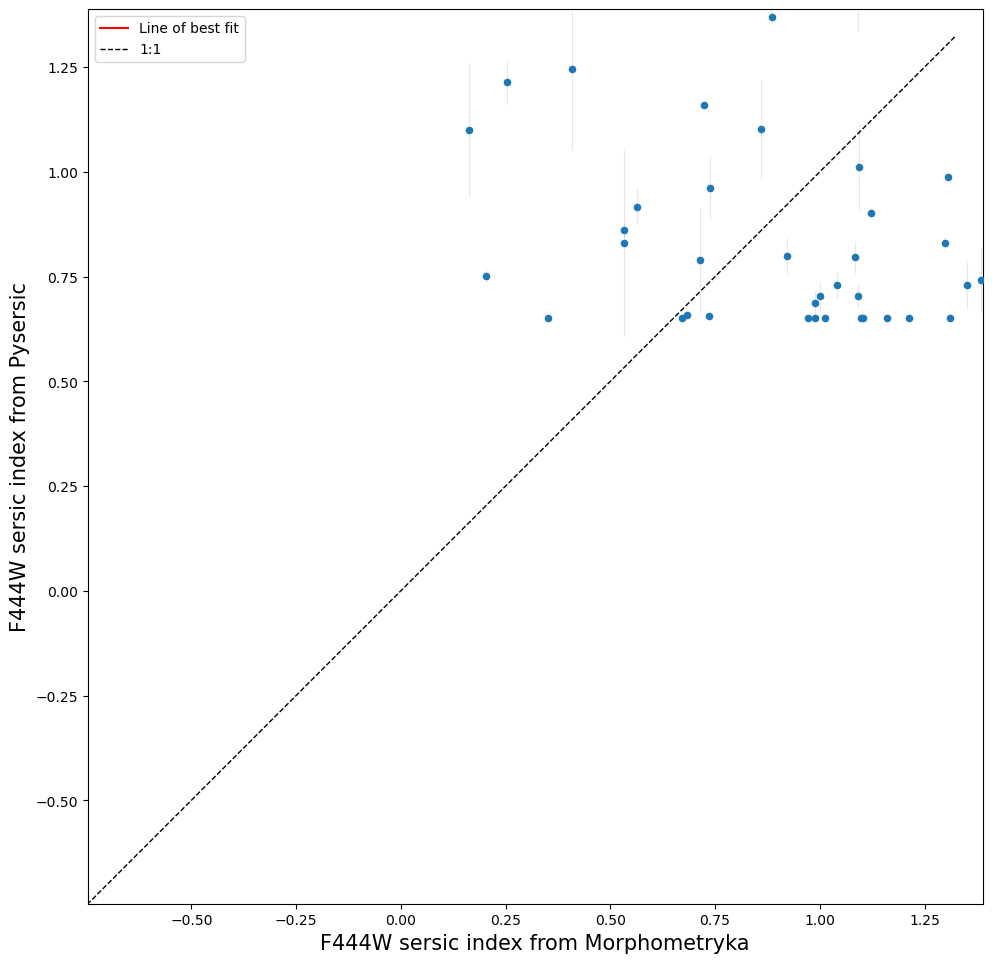

TypeError: unsupported operand type(s) for /: 'float' and 'NoneType'

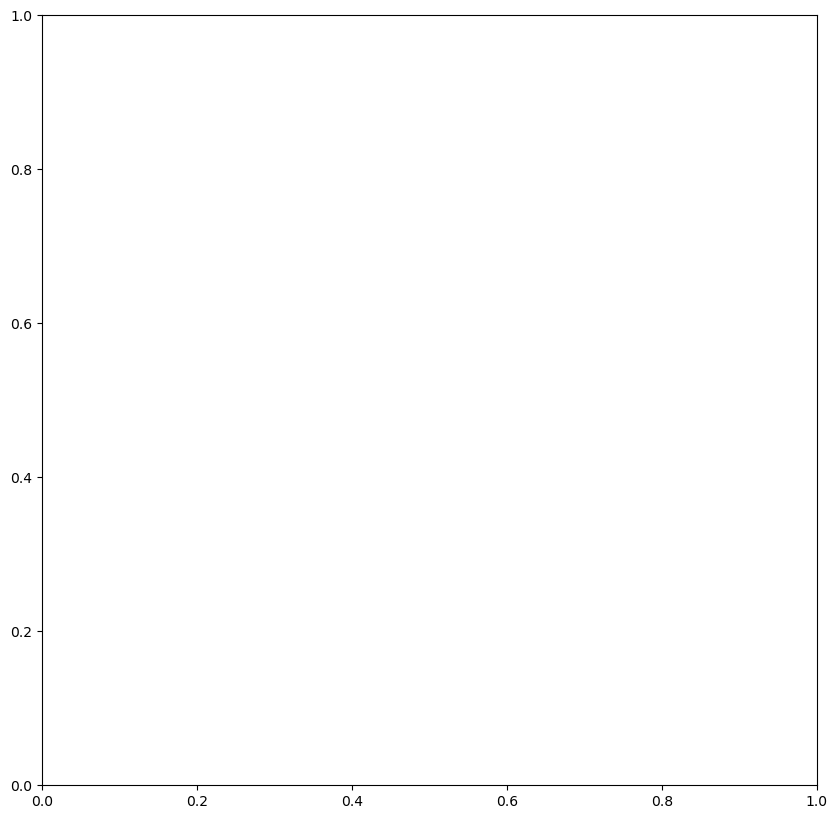

In [553]:
if __name__ == "__main__":
    
    best_model_table = compare_models()

    morphometrica_table = Table.read("/nvme/scratch/work/alberttg/Summer_project/csv_tables/Morphometrica_table_3.0as.csv", format="csv")

    statmorph_table = Table.read("/nvme/scratch/work/alberttg/Summer_project/Data_products/Statmorph_fits/Statmorph_table.fits", format="fits")

    all_combined_table = morphology_table(best_model_table, morphometrica_table, statmorph_table)

    plotting(all_combined_table)


    